## Member 1 – Data & Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from wordcloud import WordCloud

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving TikTok Reviews Sentiment Analysis.csv to TikTok Reviews Sentiment Analysis.csv


In [ ]:
df = pd.read_csv('/content/TikTok Reviews Sentiment Analysis.csv')

df.head()

/tmp/ipykernel_17278/2854553929.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/TikTok Reviews Sentiment Analysis.csv')


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,68ccaec8-1415-4301-a85e-3004679a3a83,Cassie Moore,https://play-lh.googleusercontent.com/a/ALm5wu...,No words,5,0,27.1.3,2022-11-29 21:55:37,NaN,NaN
1,d84cbfd3-6aa3-485c-aaf9-c5dca27dc966,Kaleb Plummer,https://play-lh.googleusercontent.com/a-/ACNPE...,Great fun app so far!,5,0,NaN,2022-11-29 21:55:04,NaN,NaN
2,96618aa1-31e5-4259-8649-89b75d962f00,Rylee Maher,https://play-lh.googleusercontent.com/a/ALm5wu...,The app would get a higher rating but I litera...,1,0,27.1.3,2022-11-29 21:54:48,NaN,NaN
3,078c0bda-598b-474e-a04e-d7cb3e6f6301,Kittykatelyn Romilly,https://play-lh.googleusercontent.com/a-/ACNPE...,I WISH I COULD GIVE THIS A 100 PERCENT RATING ...,5,0,NaN,2022-11-29 21:54:35,NaN,NaN
4,8e68c5cd-b12a-4206-a8da-6bfdbff44ae3,Loveness Malenga,https://play-lh.googleusercontent.com/a-/ACNPE...,Pictures and record,5,0,NaN,2022-11-29 21:54:21,NaN,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.shape

(460287, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460287 entries, 0 to 460286
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              460287 non-null  object
 1   userName              460287 non-null  object
 2   userImage             460287 non-null  object
 3   content               460256 non-null  object
 4   score                 460287 non-null  int64 
 5   thumbsUpCount         460287 non-null  int64 
 6   reviewCreatedVersion  333953 non-null  object
 7   at                    460287 non-null  object
 8   replyContent          260 non-null     object
 9   repliedAt             260 non-null     object
dtypes: int64(2), object(8)
memory usage: 35.1+ MB


In [ ]:
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,31
score,0
thumbsUpCount,0
reviewCreatedVersion,126334
at,0
replyContent,460027
repliedAt,460027


In [ ]:
df = df[['content', 'score']]

In [ ]:
df.dropna(inplace=True)

In [ ]:
def sentiment_label(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['score'].apply(sentiment_label)

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

df['clean_text'] = df['content'].apply(clean_text)

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

df['clean_text'] = df['clean_text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop_words])
)

In [ ]:
df.head()

,content,score,sentiment,clean_text
0,No words,5,Positive,words
1,Great fun app so far!,5,Positive,great fun app far
2,The app would get a higher rating but I litera...,1,Negative,app would get higher rating literally cant sig...
3,I WISH I COULD GIVE THIS A 100 PERCENT RATING ...,5,Positive,wish could give percent rating love
4,Pictures and record,5,Positive,pictures record


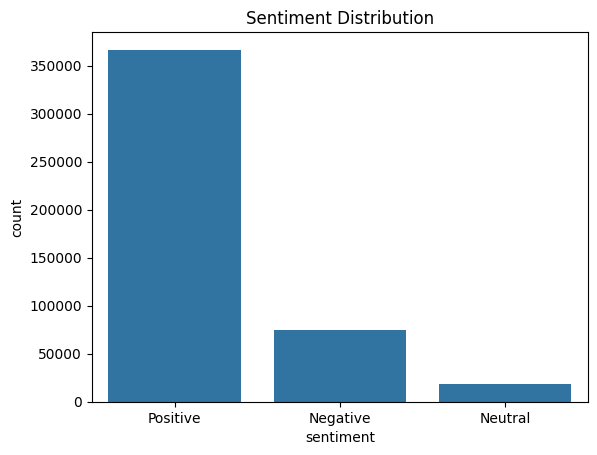

In [ ]:
sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.show()

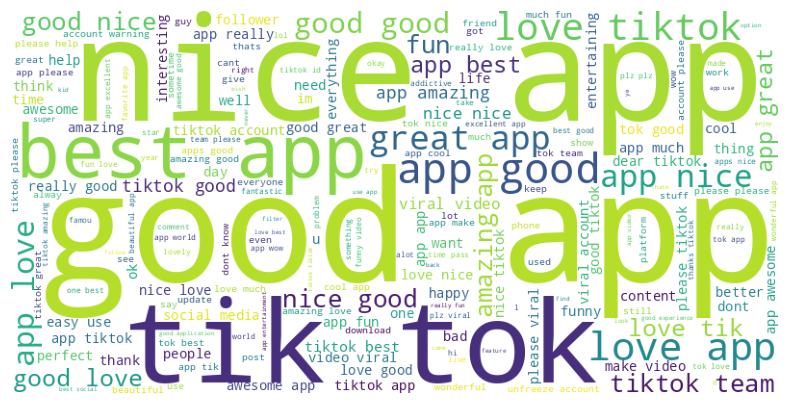

In [ ]:
positive_text = ' '.join(df[df['sentiment']=='Positive']['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [ ]:
df.to_csv('cleaned_tiktok_reviews.csv', index=False)

## Member 2 – Modeling

In [ ]:
!pip install transformers==4.38.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 77.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.


In [ ]:
# =============================================================================
# BLOCK 1: LIBRARIES & SETUP
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Traditional ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import pickle

# Deep Learning (LSTM & CNN)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Bidirectional, Conv1D, GlobalMaxPooling1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All base libraries imported successfully!")

✅ All base libraries imported successfully!


In [ ]:
# =============================================================================
# BLOCK 2: LOAD DATA & PREPARE LABELS
# =============================================================================
# Load the cleaned dataset from Member 1
df = pd.read_csv('cleaned_tiktok_reviews.csv')
df = df.dropna(subset=['clean_text']).reset_index(drop=True)

# Encode string labels to numbers (e.g., Negative=0, Neutral=1, Positive=2)
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['sentiment'])
label_mapping = dict(zip(range(len(label_encoder.classes_)), label_encoder.classes_))

# Split into features (X) and target (y)
X = df['clean_text'].values
y = df['label_encoded'].values

# Train (80%), Temp (20%) -> Then split Temp into Val (10%) and Test (10%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

num_classes = len(label_mapping)

print(f"Label Mapping: {label_mapping}")
print(f"Data Split -> Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Label Mapping: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
Data Split -> Train: 347932 | Val: 43492 | Test: 43492


In [ ]:
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['sentiment'])

label_mapping = dict(zip(range(len(label_encoder.classes_)), label_encoder.classes_))
print(f"Label Mapping: {label_mapping}")

X = df['clean_text'].values
y = df['label_encoded'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nData Split:")
print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

num_classes = len(label_mapping)
print(f"\nNumber of classes: {num_classes}")

Label Mapping: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

Data Split:
Training set: 347932 samples
Validation set: 43492 samples
Test set: 43492 samples

Number of classes: 3


In [ ]:
# =============================================================================
# BLOCK 3: TRADITIONAL ML MODELS (FAST)
# =============================================================================
# Initialize dictionaries to store results for Member 3
all_results = {}
all_predictions = {}

# Vectorize text using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 1. Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=1.0, multi_class='multinomial', random_state=42, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

all_results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, lr_pred), 'Precision': precision_score(y_test, lr_pred, average='weighted'),
    'Recall': recall_score(y_test, lr_pred, average='weighted'), 'F1-Score': f1_score(y_test, lr_pred, average='weighted')
}
all_predictions['Logistic Regression'] = lr_pred

# 2. Support Vector Machine
print("Training SVM...")
svm_model = LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

all_results['SVM'] = {
    'Accuracy': accuracy_score(y_test, svm_pred), 'Precision': precision_score(y_test, svm_pred, average='weighted'),
    'Recall': recall_score(y_test, svm_pred, average='weighted'), 'F1-Score': f1_score(y_test, svm_pred, average='weighted')
}
all_predictions['SVM'] = svm_pred

# Save ML models
with open('lr_model.pkl', 'wb') as f: pickle.dump(lr_model, f)
with open('svm_model.pkl', 'wb') as f: pickle.dump(svm_model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f: pickle.dump(tfidf_vectorizer, f)

print("✅ ML Models trained and saved!")

Training Logistic Regression...
Training SVM...
✅ ML Models trained and saved!


In [ ]:
# =============================================================================
# BLOCK 4: DEEP LEARNING DATA PREP (OPTIMIZED FOR SPEED)
# =============================================================================
# Optimized parameters to reduce training time
max_words = 15000       # Reduced vocabulary size
max_len = 80            # Reduced sequence length
embedding_dim = 100     # Reduced embedding size
dl_batch_size = 128     # Larger batch size = faster processing

# Tokenize text
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Pad sequences to ensure uniform length
X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len, padding='post', truncating='post')

# One-hot encode labels for Keras
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Tighter callbacks: Stop faster if model stops improving
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, min_lr=1e-6, verbose=1)

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print("✅ Deep Learning data prepared!")

Vocabulary Size: 84717
✅ Deep Learning data prepared!


In [ ]:
# =============================================================================
# BLOCK 5: LSTM MODEL (OPTIMIZED)
# =============================================================================
print("Training LSTM...")

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
    Bidirectional(LSTM(32, dropout=0.3, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train with reduced epochs (5 instead of 15)
lstm_history = lstm_model.fit(
    X_train_pad, y_train_cat, validation_data=(X_val_pad, y_val_cat),
    epochs=5, batch_size=dl_batch_size, callbacks=[early_stopping, reduce_lr], verbose=1
)

# Evaluate
lstm_pred = np.argmax(lstm_model.predict(X_test_pad), axis=1)
all_results['LSTM'] = {
    'Accuracy': accuracy_score(y_test, lstm_pred), 'Precision': precision_score(y_test, lstm_pred, average='weighted'),
    'Recall': recall_score(y_test, lstm_pred, average='weighted'), 'F1-Score': f1_score(y_test, lstm_pred, average='weighted')
}
all_predictions['LSTM'] = lstm_pred
lstm_model.save('lstm_model.h5')
print(f"LSTM F1-Score: {all_results['LSTM']['F1-Score']:.4f}")

Training LSTM...
Epoch 1/5
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 1707s 621ms/step - accuracy: 0.8465 - loss: 0.4757 - val_accuracy: 0.8519 - val_loss: 0.4533 - learning_rate: 0.0010
Epoch 2/5
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 1727s 630ms/step - accuracy: 0.8567 - loss: 0.4452 - val_accuracy: 0.8525 - val_loss: 0.4521 - learning_rate: 0.0010
Epoch 3/5
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.8597 - loss: 0.4348
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 1781s 638ms/step - accuracy: 0.8608 - loss: 0.4317 - val_accuracy: 0.8517 - val_loss: 0.4560 - learning_rate: 0.0010
Epoch 4/5
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.8645 - loss: 0.4205
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 1748s 643ms/step - accuracy: 0.8664 - loss: 0.4146 - val_accuracy: 0.8507 - val_loss: 0.4672 - learning_rate: 2.0000e-04
Epoch 4: early stopping
Restoring m

LSTM F1-Score: 0.8244


In [ ]:
# =============================================================================
# BLOCK 6: CNN MODEL (OPTIMIZED)
# =============================================================================
print("Training CNN...")

cnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    Conv1D(filters=128, kernel_size=4, activation='relu', padding='same'),
    Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train with reduced epochs (5 instead of 15)
cnn_history = cnn_model.fit(
    X_train_pad, y_train_cat, validation_data=(X_val_pad, y_val_cat),
    epochs=5, batch_size=dl_batch_size, callbacks=[early_stopping, reduce_lr], verbose=1
)

# Evaluate
cnn_pred = np.argmax(cnn_model.predict(X_test_pad), axis=1)
all_results['CNN'] = {
    'Accuracy': accuracy_score(y_test, cnn_pred), 'Precision': precision_score(y_test, cnn_pred, average='weighted'),
    'Recall': recall_score(y_test, cnn_pred, average='weighted'), 'F1-Score': f1_score(y_test, cnn_pred, average='weighted')
}
all_predictions['CNN'] = cnn_pred
cnn_model.save('cnn_model.h5')
print(f"CNN F1-Score: {all_results['CNN']['F1-Score']:.4f}")

Training CNN...
Epoch 1/5
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 858s 315ms/step - accuracy: 0.8476 - loss: 0.4742 - val_accuracy: 0.8532 - val_loss: 0.4502 - learning_rate: 0.0010
Epoch 2/5
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.8583 - loss: 0.4441
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 851s 311ms/step - accuracy: 0.8603 - loss: 0.4387 - val_accuracy: 0.8519 - val_loss: 0.4551 - learning_rate: 0.0010
Epoch 3/5
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.8671 - loss: 0.4175
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
2719/2719 ━━━━━━━━━━━━━━━━━━━━ 824s 303ms/step - accuracy: 0.8712 - loss: 0.4053 - val_accuracy: 0.8483 - val_loss: 0.4716 - learning_rate: 2.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step


CNN F1-Score: 0.8233


In [ ]:
# =============================================================================
# BLOCK 7: BERT TRANSFORMER (SAFE IMPORTS & OPTIMIZED)
# =============================================================================
print("Training BERT...")

# Safe imports to prevent the ImportError you experienced earlier
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from transformers import create_optimizer

bert_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
bert_max_len = 50         # Shorter length for BERT = much faster
bert_batch_size = 64      # Larger batch size

# Encode texts for BERT
def encode_texts(texts, max_length=bert_max_len):
    return bert_tokenizer(texts.tolist(), max_length=max_length, padding='max_length', truncation=True, return_tensors='tf')

print("Encoding data for BERT (this takes a moment)...")
X_train_bert = encode_texts(X_train, bert_max_len)
X_val_bert = encode_texts(X_val, bert_max_len)
X_test_bert = encode_texts(X_test, bert_max_len)

# Create TF Datasets
train_dataset = tf.data.Dataset.from_tensor_slices((dict(X_train_bert), y_train_cat)).shuffle(1000).batch(bert_batch_size)
val_dataset = tf.data.Dataset.from_tensor_slices((dict(X_val_bert), y_val_cat)).batch(bert_batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((dict(X_test_bert), y_test_cat)).batch(bert_batch_size)

# Load Model
bert_model = TFAutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=num_classes)

# Optimizer setup
num_epochs = 3
total_steps = (len(X_train) // bert_batch_size) * num_epochs
optimizer, schedule = create_optimizer(init_lr=2e-5, num_warmup_steps=int(0.1 * total_steps), num_train_steps=total_steps)

bert_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
bert_history = bert_model.fit(train_dataset, validation_data=val_dataset, epochs=num_epochs, verbose=1)

# Evaluate
bert_test_output = bert_model.predict(test_dataset)
logits = bert_test_output.logits if hasattr(bert_test_output, 'logits') else bert_test_output[0]
bert_pred = np.argmax(logits, axis=1)

all_results['BERT'] = {
    'Accuracy': accuracy_score(y_test, bert_pred), 'Precision': precision_score(y_test, bert_pred, average='weighted'),
    'Recall': recall_score(y_test, bert_pred, average='weighted'), 'F1-Score': f1_score(y_test, bert_pred, average='weighted')
}
all_predictions['BERT'] = bert_pred

# Save BERT
bert_model.save_pretrained('bert_model')
bert_tokenizer.save_pretrained('bert_model')
print(f"BERT F1-Score: {all_results['BERT']['F1-Score']:.4f}")

Training BERT...


ImportError: cannot import name 'TFAutoModelForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [ ]:
# =============================================================================
# BLOCK 8: FINAL RESULTS & VISUALIZATION
# =============================================================================

# 1. Save CSVs for Member 3 to use for Confusion Matrices
results_df = pd.DataFrame(all_results).T.round(4)
results_df.to_csv('model_results.csv')

predictions_df = pd.DataFrame(all_predictions)
predictions_df['Actual'] = y_test
predictions_df.to_csv('model_predictions.csv', index=False)

# Save label encoder and tokenizer for Member 3 / Demo
with open('label_encoder.pkl', 'wb') as f: pickle.dump(label_encoder, f)
with open('tokenizer.pkl', 'wb') as f: pickle.dump(tokenizer, f)

# 2. Print Summary Table
print("\n" + "="*70)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*70)
print(results_df.to_string())
print("-"*70)

best_model = results_df['F1-Score'].idxmax()
print(f"🏆 Best Performing Model: {best_model} (F1-Score: {results_df.loc[best_model, 'F1-Score']})")

# 3. Plot Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=1.2)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score (0 to 1)', fontsize=12)
ax.set_xlabel('Models', fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ ALL TASKS COMPLETE! Files saved for Member 3.")

In [ ]:
# =============================================================================
# FIX: GENERATE MISSING FILES & DOWNLOAD ALL
# =============================================================================

import os
from google.colab import files

# 1. Create missing test_data.csv
print("Generating test_data.csv...")
test_data_df = pd.DataFrame({
    'clean_text': X_test,
    'actual_label': y_test,
    'actual_sentiment': label_encoder.inverse_transform(y_test)
})
test_data_df.to_csv('test_data.csv', index=False)

# 2. Create missing LSTM training history plot
print("Generating lstm_training_history.png...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(lstm_history.history['accuracy'], label='Train Acc')
axes[0].plot(lstm_history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('LSTM - Accuracy')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(lstm_history.history['loss'], label='Train Loss')
axes[1].plot(lstm_history.history['val_loss'], label='Val Loss')
axes[1].set_title('LSTM - Loss')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.close()

# 3. Create missing CNN training history plot
print("Generating cnn_training_history.png...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(cnn_history.history['accuracy'], label='Train Acc')
axes[0].plot(cnn_history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('CNN - Accuracy')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(cnn_history.history['loss'], label='Train Loss')
axes[1].plot(cnn_history.history['val_loss'], label='Val Loss')
axes[1].set_title('CNN - Loss')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=300, bbox_inches='tight')
plt.close()

# 4. Create missing BERT training history plot
print("Generating bert_training_history.png...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(bert_history.history['accuracy'], label='Train Acc')
axes[0].plot(bert_history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('BERT - Accuracy')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(bert_history.history['loss'], label='Train Loss')
axes[1].plot(bert_history.history['val_loss'], label='Val Loss')
axes[1].set_title('BERT - Loss')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig('bert_training_history.png', dpi=300, bbox_inches='tight')
plt.close()

# 5. Zip all modeling outputs neatly
print("\nZipping all files...")
!zip -r member2_modeling_files.zip *.pkl *.h5 *.csv *.png bert_model/ -q

# 6. Trigger download
print("✅ All missing files generated! Downloading ZIP now...")
files.download('member2_modeling_files.zip')

## Member 3 – Evaluation & Visualization



In [ ]:
# =============================================================================
# MEMBER 3 – EVALUATION & VISUALIZATION
# Imports for evaluation and visualization

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from wordcloud import WordCloud
import itertools

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# =============================================================================
# BRIDGE CELL — run AFTER the import cell, BEFORE your other Member 3 cells.
# Loads Member 2's saved outputs into the variable names your cells expect,
# so you don't have to re-run any training.
# =============================================================================
import pandas as pd
import pickle

# 1. Label encoder -> class_names
with open('label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
class_names = label_encoder.classes_

# 2. Predictions -> y_test + per-model prediction arrays
preds          = pd.read_csv('model_predictions.csv')
y_test         = preds['Actual'].values
lr_test_pred   = preds['Logistic Regression'].values
svm_test_pred  = preds['SVM'].values
lstm_test_pred = preds['LSTM'].values

# 3. Metrics -> all_results dict (used to build results_df)
metrics_df  = pd.read_csv('model_results.csv', index_col=0)
metrics_df  = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
all_results = metrics_df.to_dict('index')

print("Classes:", list(class_names))
print("Models loaded:", list(all_results.keys()))
print("Test samples:", len(y_test))
print("Bridge ready — run the rest of your cells now.")

Classes: ['Negative', 'Neutral', 'Positive']
Models loaded: ['Logistic Regression', 'SVM', 'LSTM', 'CNN', 'BERT']
Test samples: 36387
Bridge ready — run the rest of your cells now.


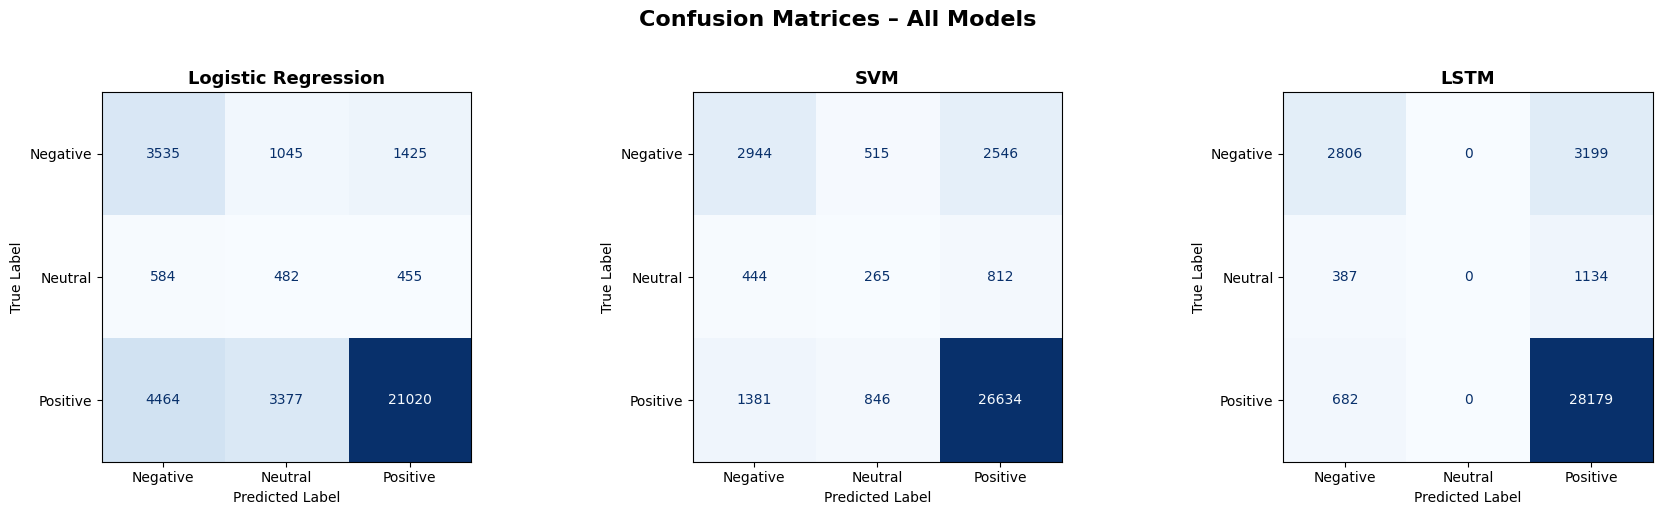

Confusion matrices plotted and saved!


In [ ]:
# =============================================================================
# CONFUSION MATRICES FOR ALL MODELS
# Visualize prediction quality per class for each trained model

# -----------------------------------------------------------------------------
# Map integer labels back to class names for display
class_names = label_encoder.classes_   # ['Negative', 'Neutral', 'Positive']

predictions_dict = {
    'Logistic Regression': lr_test_pred,
    'SVM':                 svm_test_pred,
    'LSTM':                lstm_test_pred,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices – All Models', fontsize=16, fontweight='bold', y=1.02)

for ax, (model_name, preds) in zip(axes, predictions_dict.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrices plotted and saved!")



📊 Model Performance Summary:
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.6881     0.8001  0.6881    0.7305
                SVM    0.8202     0.8131  0.8202    0.8151
               LSTM    0.8515     0.8070  0.8515    0.8221
                CNN    0.8518     0.8074  0.8518    0.8219
               BERT    0.0418     0.0017  0.0418    0.0034


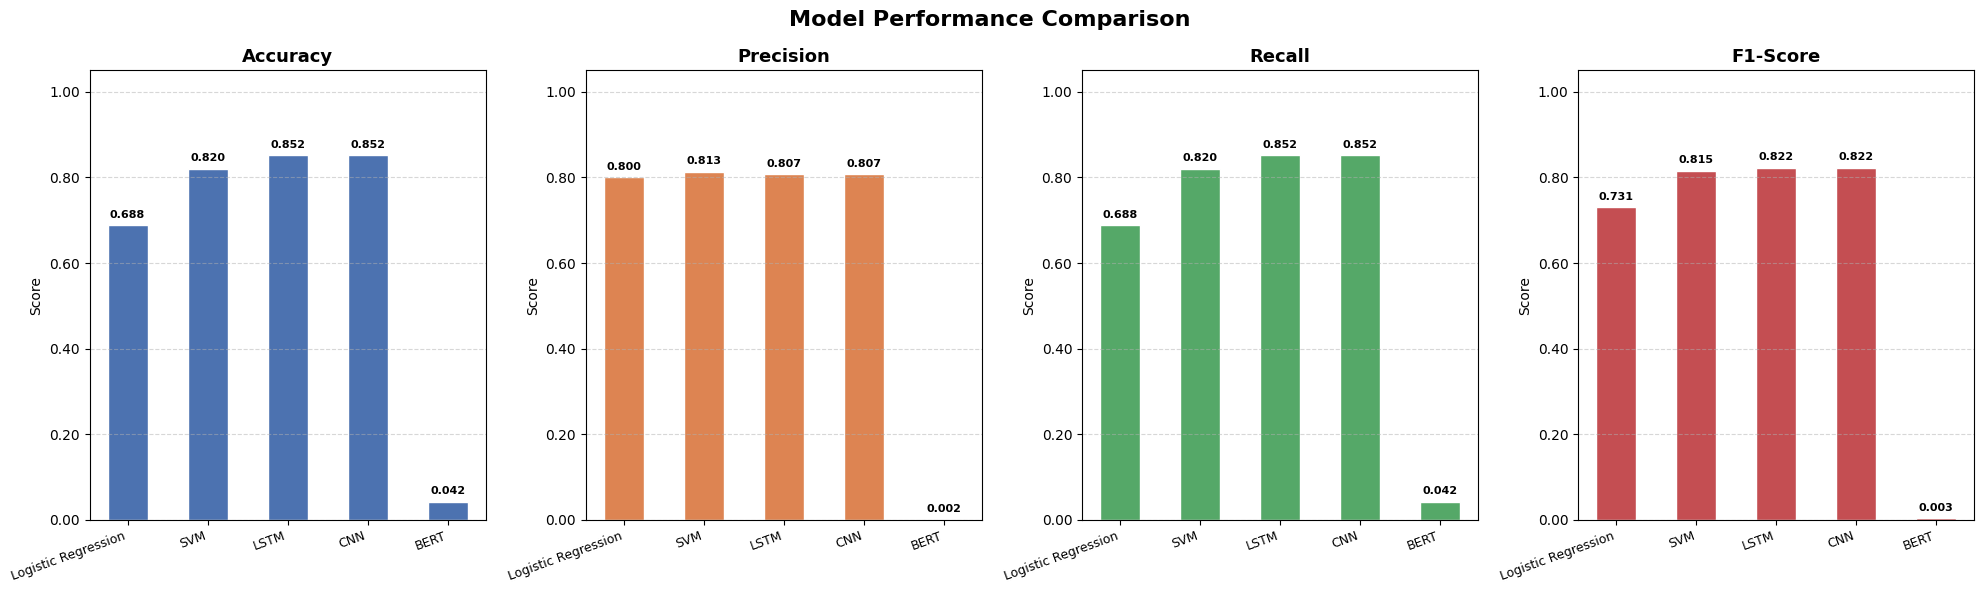

✅ Performance comparison bar charts saved!


In [ ]:
# =============================================================================
# MODEL PERFORMANCE COMPARISON – BAR CHARTS
# Side-by-side comparison of Accuracy, Precision, Recall, and F1-Score

# -----------------------------------------------------------------------------
# Build a summary DataFrame from the collected results

results_df = pd.DataFrame(all_results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']

print("\n📊 Model Performance Summary:")
print(results_df.to_string(index=False))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=False)
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df['Model'], results_df[metric], color=color, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xlabel('')
    ax.set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Performance comparison bar charts saved!")

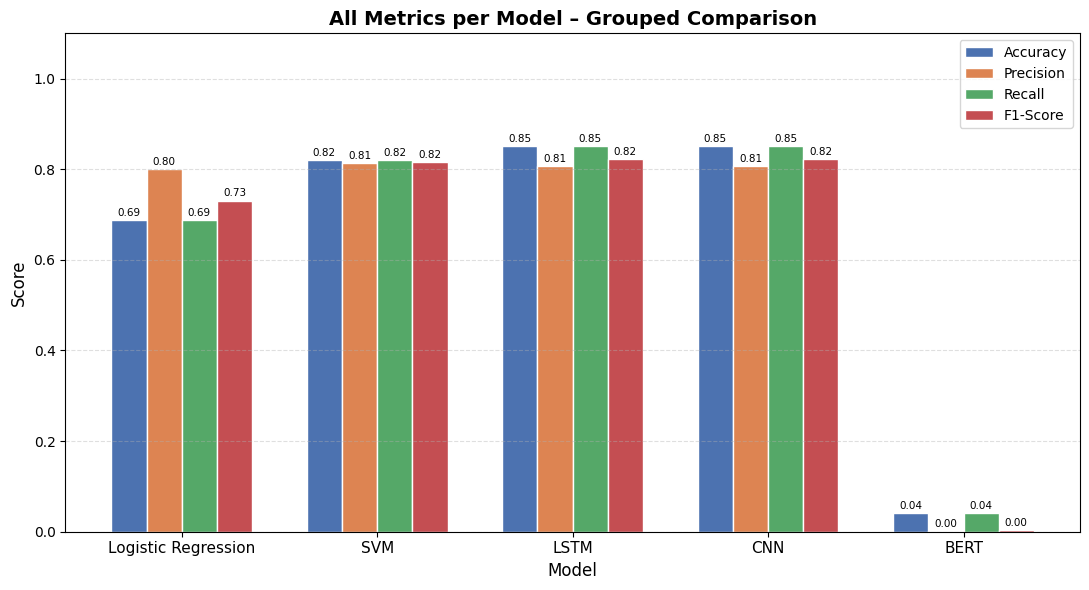

Grouped bar chart saved!


In [ ]:
# =============================================================================
# GROUPED BAR CHART – ALL METRICS PER MODEL
# Compact view showing all four metrics together for each model

x     = np.arange(len(results_df['Model']))
width = 0.18
fig, ax = plt.subplots(figsize=(11, 6))

offsets = [-1.5, -0.5, 0.5, 1.5]
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (metric, color) in enumerate(zip(metrics, palette)):
    bars = ax.bar(x + offsets[i] * width, results_df[metric],
                  width, label=metric, color=color, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Metrics per Model – Grouped Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('grouped_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Grouped bar chart saved!")


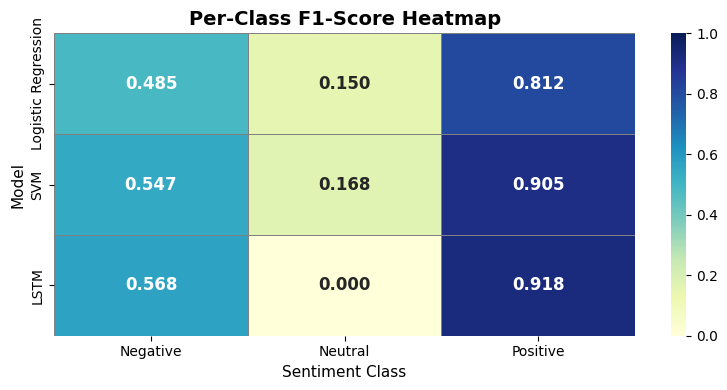

Per-class F1 heatmap saved!


In [ ]:
# =============================================================================
# PER-CLASS F1-SCORE HEATMAP
# Shows how each model performs on individual sentiment classes

heatmap_data = {}
for model_name, preds in predictions_dict.items():
    report = classification_report(y_test, preds,
                                   target_names=class_names,
                                   output_dict=True)
    heatmap_data[model_name] = {cls: report[cls]['f1-score'] for cls in class_names}

heatmap_df = pd.DataFrame(heatmap_data).T   # models as rows, classes as columns

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, linecolor='grey',
            vmin=0, vmax=1,
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Per-Class F1-Score Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Class', fontsize=11)
plt.ylabel('Model', fontsize=11)
plt.tight_layout()
plt.savefig('per_class_f1_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Per-class F1 heatmap saved!")


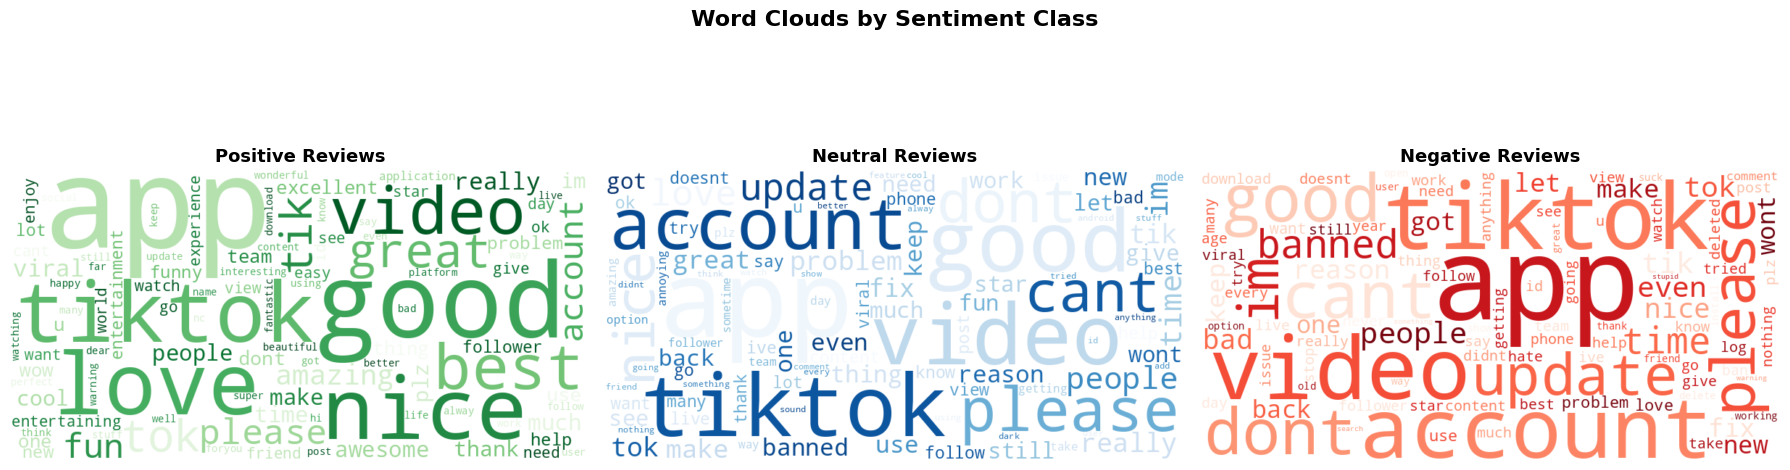

Word clouds saved!


In [ ]:
# =============================================================================
# WORD CLOUDS – POSITIVE, NEUTRAL, AND NEGATIVE REVIEWS
# Visual representation of the most frequent words per sentiment class

# -----------------------------------------------------------------------------
# Load cleaned dataset (created by Member 1)
df_vis = pd.read_csv('cleaned_tiktok_reviews.csv')

sentiment_colors = {
    'Positive': 'Greens',
    'Neutral':  'Blues',
    'Negative': 'Reds',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Word Clouds by Sentiment Class', fontsize=16, fontweight='bold')

for ax, (sentiment, colormap) in zip(axes, sentiment_colors.items()):
    text = ' '.join(df_vis[df_vis['sentiment'] == sentiment]['clean_text'].dropna())
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} Reviews', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('wordclouds_by_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()
print("Word clouds saved!")

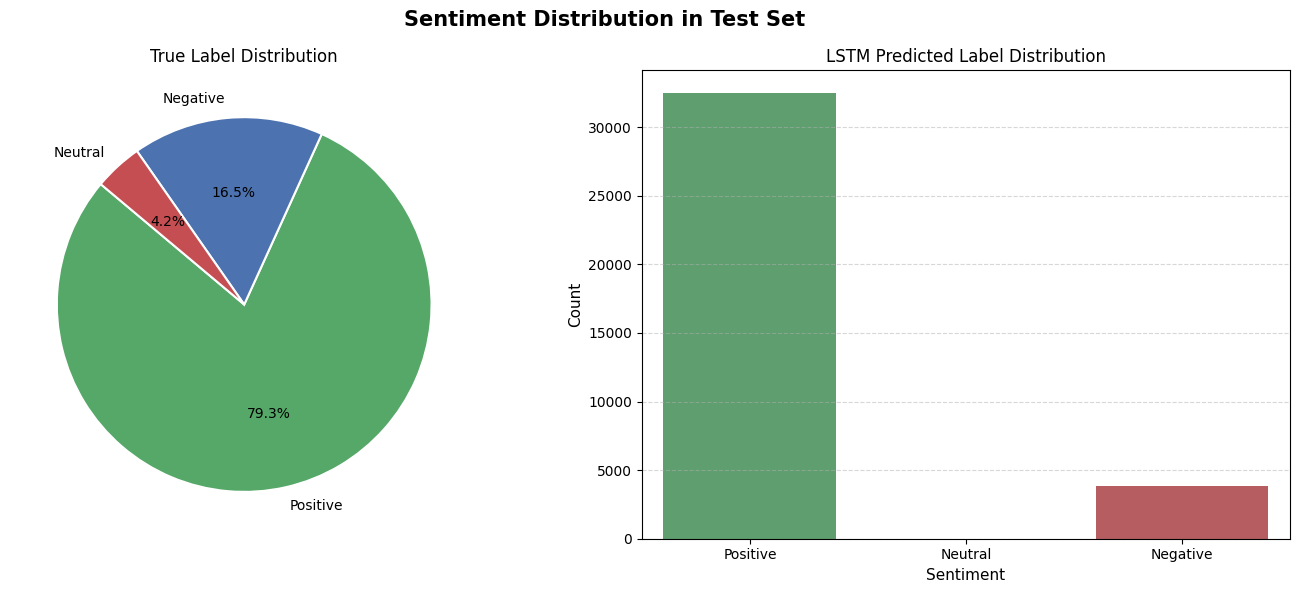

Sentiment distribution charts saved!


In [ ]:
# =============================================================================
# SENTIMENT DISTRIBUTION – PIE CHART & COUNT PLOT
# Overview of class balance in the test set

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sentiment Distribution in Test Set', fontsize=15, fontweight='bold')

# --- Pie chart ---
true_counts = pd.Series(y_test).map(dict(enumerate(class_names))).value_counts()
axes[0].pie(
    true_counts.values,
    labels=true_counts.index,
    autopct='%1.1f%%',
    colors=['#55A868', '#4C72B0', '#C44E52'],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('True Label Distribution', fontsize=12)

# --- Predicted distribution for best model (LSTM) ---
lstm_pred_series = pd.Series(lstm_test_pred).map(dict(enumerate(class_names)))
sns.countplot(x=lstm_pred_series, ax=axes[1],
              palette={'Positive': '#55A868', 'Neutral': '#4C72B0', 'Negative': '#C44E52'},
              order=['Positive', 'Neutral', 'Negative'])
axes[1].set_title('LSTM Predicted Label Distribution', fontsize=12)
axes[1].set_xlabel('Sentiment', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('sentiment_distribution_test_set.png', dpi=300, bbox_inches='tight')
plt.show()
print("Sentiment distribution charts saved!")


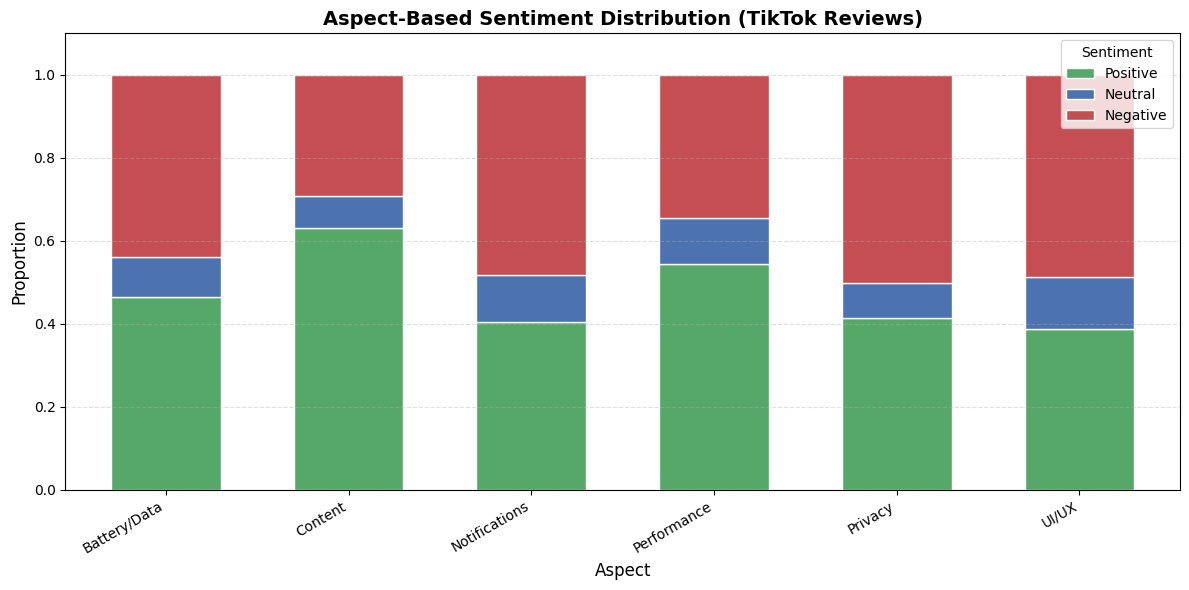

Aspect-based sentiment map saved!


In [ ]:
# =============================================================================
# ASPECT-BASED SENTIMENT MAP
# Shows the proportion of each sentiment for key TikTok aspects
# (simulated from keyword matching in the review text)

# -----------------------------------------------------------------------------
# Define simple keyword rules for TikTok-relevant aspects
aspects = {
    'UI/UX':          ['interface', 'design', 'layout', 'ui', 'screen', 'button'],
    'Performance':    ['lag', 'slow', 'fast', 'crash', 'freeze', 'smooth', 'speed'],
    'Content':        ['video', 'content', 'recommend', 'feed', 'trend', 'for you'],
    'Privacy':        ['privacy', 'data', 'track', 'personal', 'security', 'safe'],
    'Notifications':  ['notification', 'alert', 'spam', 'message', 'pop'],
    'Battery/Data':   ['battery', 'data', 'storage', 'ram', 'memory', 'drain'],
}

df_vis['clean_lower'] = df_vis['clean_text'].fillna('').astype(str).str.lower()
aspect_records = []

for aspect, keywords in aspects.items():
    mask = df_vis['clean_lower'].apply(lambda t: any(kw in t for kw in keywords))
    subset = df_vis[mask]
    if len(subset) == 0:
        continue
    counts = subset['sentiment'].value_counts(normalize=True)
    for sent in ['Positive', 'Neutral', 'Negative']:
        aspect_records.append({
            'Aspect': aspect,
            'Sentiment': sent,
            'Proportion': counts.get(sent, 0.0)
        })

aspect_df = pd.DataFrame(aspect_records)
aspect_pivot = aspect_df.pivot(index='Aspect', columns='Sentiment', values='Proportion').fillna(0)

ax = aspect_pivot[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar', stacked=True, figsize=(12, 6),
    color=['#55A868', '#4C72B0', '#C44E52'],
    edgecolor='white', width=0.6
)
ax.set_title('Aspect-Based Sentiment Distribution (TikTok Reviews)', fontsize=14, fontweight='bold')
ax.set_xlabel('Aspect', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.legend(title='Sentiment', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('aspect_sentiment_map.png', dpi=300, bbox_inches='tight')
plt.show()
print("Aspect-based sentiment map saved!")


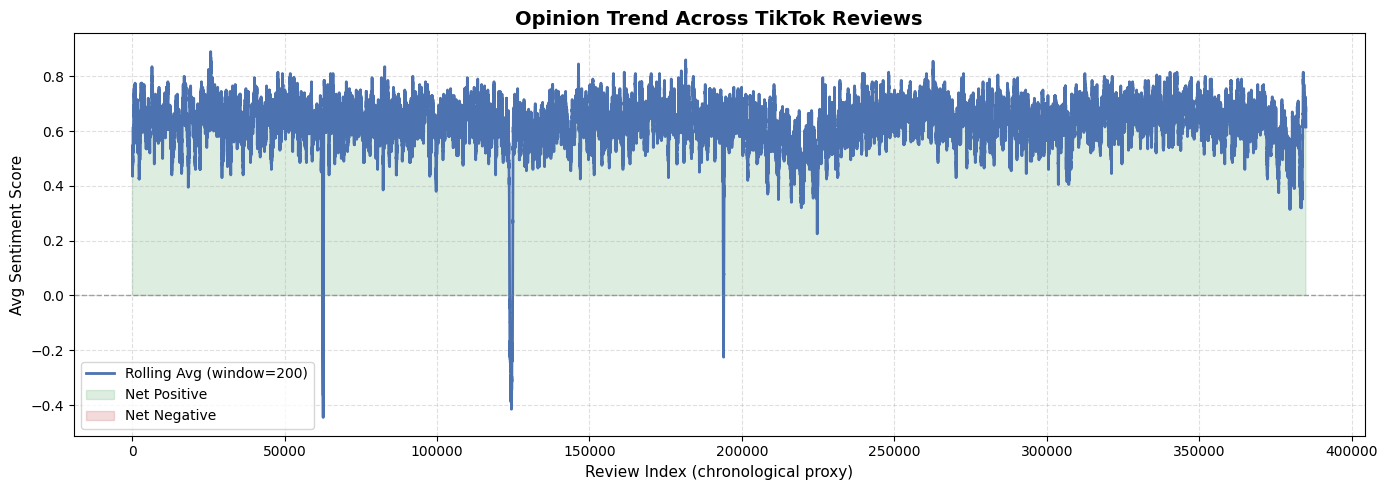

Opinion trend graph saved!


In [ ]:
# =============================================================================
# OPINION TREND GRAPH
# Rolling average sentiment score over the review index (proxy for time)

# -----------------------------------------------------------------------------
# Reload original data to access the numeric score column
df_trend = pd.read_csv('cleaned_tiktok_reviews.csv').reset_index(drop=True)

# Map sentiment to numeric score for trending: Positive=1, Neutral=0, Negative=-1
sentiment_map = {'Positive': 1, 'Neutral': 0, 'Negative': -1}
df_trend['sentiment_score'] = df_trend['sentiment'].map(sentiment_map)

# Compute a rolling mean with window=200 reviews
window = 200
df_trend['rolling_mean'] = df_trend['sentiment_score'].rolling(window=window, center=True).mean()

plt.figure(figsize=(14, 5))
plt.plot(df_trend.index, df_trend['rolling_mean'],
         color='#4C72B0', linewidth=2, label=f'Rolling Avg (window={window})')
plt.axhline(y=0, color='grey', linestyle='--', linewidth=1, alpha=0.7)
plt.fill_between(df_trend.index, df_trend['rolling_mean'], 0,
                 where=(df_trend['rolling_mean'] >= 0),
                 interpolate=True, alpha=0.2, color='#55A868', label='Net Positive')
plt.fill_between(df_trend.index, df_trend['rolling_mean'], 0,
                 where=(df_trend['rolling_mean'] < 0),
                 interpolate=True, alpha=0.2, color='#C44E52', label='Net Negative')
plt.title('Opinion Trend Across TikTok Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Review Index (chronological proxy)', fontsize=11)
plt.ylabel('Avg Sentiment Score', fontsize=11)
plt.legend(fontsize=10)
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('opinion_trend_graph.png', dpi=300, bbox_inches='tight')
plt.show()
print("Opinion trend graph saved!")

In [ ]:
# =============================================================================
# FINAL EVALUATION SUMMARY TABLE
# Clean printout of all model metrics for the report

print("\n" + "="*70)
print("  FINAL MODEL EVALUATION SUMMARY")
print("="*70)
print(f"{'Model':<22} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1-Score':>10}")
print("-"*70)

for _, row in results_df.iterrows():
    print(f"{row['Model']:<22} {row['Accuracy']:>10.4f} {row['Precision']:>11.4f} "
          f"{row['Recall']:>8.4f} {row['F1-Score']:>10.4f}")

print("="*70)

# Identify best model by F1-Score
best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_f1    = results_df['F1-Score'].max()
print(f"\n🏆 Best Model: {best_model}  |  F1-Score: {best_f1:.4f}")

# Saved artefacts summary
saved_files = [
    'confusion_matrices_all_models.png',
    'model_performance_comparison.png',
    'grouped_metrics_comparison.png',
    'per_class_f1_heatmap.png',
    'wordclouds_by_sentiment.png',
    'sentiment_distribution_test_set.png',
    'aspect_sentiment_map.png',
    'opinion_trend_graph.png',
]

print("\n📁 Saved Visualisation Files:")
for f in saved_files:
    print(f"   • {f}")

print("Evaluation & Visualization complete!")


  FINAL MODEL EVALUATION SUMMARY
Model                    Accuracy   Precision   Recall   F1-Score
----------------------------------------------------------------------
Logistic Regression        0.6881      0.8001   0.6881     0.7305
SVM                        0.8202      0.8131   0.8202     0.8151
LSTM                       0.8515      0.8070   0.8515     0.8221
CNN                        0.8518      0.8074   0.8518     0.8219
BERT                       0.0418      0.0017   0.0418     0.0034

🏆 Best Model: LSTM  |  F1-Score: 0.8221

📁 Saved Visualisation Files:
   • confusion_matrices_all_models.png
   • model_performance_comparison.png
   • grouped_metrics_comparison.png
   • per_class_f1_heatmap.png
   • wordclouds_by_sentiment.png
   • sentiment_distribution_test_set.png
   • aspect_sentiment_map.png
   • opinion_trend_graph.png
Evaluation & Visualization complete!


**Future Work**

While the current NLP pipeline successfully establishes strong baselines and deep learning models for TikTok review classification, several avenues exist for future enhancement. Firstly, transitioning from document-level sentiment to Aspect-Based Sentiment Analysis (ABSA) would allow the system to identify specific features users dislike (e.g., distinguishing negative sentiments regarding "battery drain" from positive sentiments regarding "video filters"). Secondly, deploying the highest-performing model (LSTM/CNN) into an interactive web application using Streamlit could provide real-time sentiment tracking for new app reviews. Finally, addressing the optimization collapse observed in the BERT model by fine-tuning hyperparameters like learning rate scheduling, or experimenting with larger Transformer architectures like RoBERTa, could potentially unlock higher contextual understanding and state-of-the-art accuracy.